In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import torch

import torch.nn.functional as F

In [2]:
supplementary_train = pd.read_csv('./Hackathon_training/Training_supplementary_data.csv')
print(supplementary_train.head())

   Unnamed: 0  planet_ID  star_distance  star_mass_kg  star_radius_m  \
0       21988      21988        705.851  5.346528e+30   2.344509e+09   
1       21989      21989       1008.790  2.306555e+30   1.140948e+09   
2       21990      21990       1175.220  2.048062e+30   7.165710e+08   
3       21991      21991        758.199  1.689751e+30   6.962079e+08   
4       21992      21992        769.200  1.809453e+30   6.052590e+08   

   star_temperature  planet_mass_kg  planet_orbital_period  planet_distance  \
0            9195.0    9.718181e+26              10.911880         0.133882   
1            6200.0    5.504200e+25              30.652800         0.201421   
2            5825.0    5.694000e+25              85.735028         0.384318   
3            5430.0    4.636715e+26               2.150451         0.030883   
4            5485.0    3.226600e+25              13.646182         0.108308   

   planet_radius_m  planet_surface_gravity  
0     8.800980e+07                8.008170  
1 

In [3]:
targets = pd.read_csv("./Hackathon_training/Training_targets.csv")
targets = targets.drop('Unnamed: 0', axis=1)
print(targets.head())

   planet_ID  planet_temp   log_H2O   log_CO2   log_CH4    log_CO   log_NH3
0      21988  2224.531730 -3.303530 -7.806218 -5.290638 -3.014111 -6.984789
1      21989   853.088814 -6.501423 -5.629568 -5.718509 -3.686237 -7.810404
2      21990   459.835595 -8.896195 -5.369230 -7.497746 -4.715665 -8.714435
3      21991  1490.487796 -6.341209 -8.888491 -4.390208 -3.852177 -4.709982
4      21992   749.616817 -8.381343 -8.683512 -4.697381 -4.068019 -4.470251


In [4]:
def load_spectral_data(spectral_data_path):
    with h5py.File(spectral_data_path, "r") as h5f:
        n_planets = len(h5f.keys())
        noise_stack    = np.zeros((n_planets, 52))
        spectrum_stack = np.zeros((n_planets, 52))

        for i, planet in enumerate(h5f.keys()):
            spectrum_stack[i] = h5f[planet]['instrument_spectrum'][:]
            noise_stack[i]    = h5f[planet]['instrument_noise'][:]

        first = next(iter(h5f.keys()))
        wl_grid = h5f[first]['instrument_wlgrid'][:]
        width   = h5f[first]['instrument_width'][:]

    return spectrum_stack, noise_stack, wl_grid, width

In [5]:
spectrum_stack_training, noise_stack_training, wl_grid_training, width_training = load_spectral_data('./Hackathon_training/Training_SpectralData.hdf5')

In [6]:
x_combined = np.stack([spectrum_stack_training, noise_stack_training], axis=1)
y = targets.iloc[:,1:].values
x_supplementary = supplementary_train.iloc[:,2:].values

X_temp_spec, X_test_spec, X_temp_supp, X_test_supp, y_temp, y_test = train_test_split(x_combined,x_supplementary,y,test_size=0.2,random_state=42)

X_train_spec, X_val_spec, X_train_supp, X_val_supp, y_train, y_val = train_test_split(X_temp_spec, X_temp_supp, y_temp,test_size=0.2,random_state=42)

print(f"Training set size: {X_train_spec.shape[0]} planets")
print(f"Validation set size: {X_val_spec.shape[0]} planets")
print(f"testing set size: {X_test_spec.shape[0]} planets")

Training set size: 44418 planets
Validation set size: 11105 planets
testing set size: 13881 planets


In [7]:
from sklearn.preprocessing import StandardScaler
target_scaler = StandardScaler()
supp_scaler = StandardScaler()
X_train_supp_scaled = supp_scaler.fit_transform(X_train_supp)
y_train_scaled = target_scaler.fit_transform(y_train)
X_val_supp_scaled = supp_scaler.transform(X_val_supp)
y_val_scaled = target_scaler.transform(y_val)

In [8]:
import torch.nn as nn
class CombineDataset(Dataset):
    def __init__(self,spectra,supplementary = None,targets = None):
        self.spectra = spectra
        self.targets = targets
        self.supplementary = supplementary
    def __len__(self):
        return len(self.spectra)
    def __getitem__(self, idx):
        x_spec = torch.from_numpy(self.spectra[idx])
        output = [x_spec]
        if self.supplementary is not None:
            output.append(torch.from_numpy(self.supplementary[idx]))
        if self.targets is not None:
            output.append(torch.from_numpy(self.targets[idx]))
        return output

In [9]:
from torch.utils.data import DataLoader

train_dataset = CombineDataset(X_train_spec,X_train_supp_scaled,y_train_scaled)
val_dataset = CombineDataset(X_val_spec, X_val_supp_scaled, y_val_scaled)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

for spec, supp, target in train_loader:
    print("Batch Spectrum Shape:", spec.shape)  # Should be [64, 2, Sequence_Length]
    print("Batch Supp Shape:", supp.shape)      # Should be [64, N_Supp_Features]
    print("Batch Target Shape:", target.shape)  # Should be [64, 6]
    break

Batch Spectrum Shape: torch.Size([64, 2, 52])
Batch Supp Shape: torch.Size([64, 9])
Batch Target Shape: torch.Size([64, 6])


In [10]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(113, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 6)
        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.2)

    def forward(self, spec, supp):
        spec_flat = spec.view(spec.shape[0], -1)
        x = torch.cat([spec_flat, supp], dim=1)
        x = x.float()
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x

model = MLP()


In [11]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [12]:
def weighted_mse_loss(pred, target):

    squared_error = (pred - target) ** 2

    weights = torch.tensor([1.0, 5.0, 5.0, 5.0, 5.0, 5.0]).to(pred.device)


    weighted_error = squared_error * weights
    return weighted_error.mean()

In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, channel1, channel2, res_stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(channel1, channel2, stride=res_stride, kernel_size=3, padding=1),
            nn.BatchNorm1d(channel2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(channel2, channel2, stride=1, kernel_size=3, padding=1),
            nn.BatchNorm1d(channel2),
        )
        if res_stride != 1 or channel2 != channel1:
            self.skip = nn.Sequential(
                nn.Conv1d(channel1, channel2, stride=res_stride, kernel_size=1, padding=0),
                nn.BatchNorm1d(channel2)
            )
        else:
            self.skip = nn.Sequential()

    def forward(self, x):
        out = self.conv1(x)
        out = F.relu(out)
        out = self.conv2(out)
        out += self.skip(x)
        out = F.relu(out)
        return out


class ResnetEncoder(nn.Module):
    def __init__(self, blocks, num_blocks, strides, num_features, input_channels=2, num_supplementary=9):
        super(ResnetEncoder, self).__init__()
        self.num_channel_output = num_features[0]
        self.initial_conv = nn.Sequential(
            nn.Conv1d(input_channels, num_features[0], kernel_size=3, stride=strides[0], padding=1),
            nn.BatchNorm1d(num_features[0]),
        )
        self.layer1 = self._make_layer(blocks, num_blocks, strides[1], num_features[1])
        self.layer2 = self._make_layer(blocks, num_blocks, strides[2], num_features[2])
        self.layer3 = self._make_layer(blocks, num_blocks, strides[3], num_features[3])
        self.layer4 = self._make_layer(blocks, num_blocks, strides[4], num_features[4])
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)

        self.final_layers = nn.Sequential(
            nn.Linear(num_features[4] + num_supplementary, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 6)   # fix 3: was 1, needs to be 6 targets
        )

    def _make_layer(self, blocks, num_blocks, strides, num_features):
        layers = []
        layers.append(blocks(self.num_channel_output, num_features, strides))
        self.num_channel_output = num_features
        for _ in range(num_blocks - 1):
            layers.append(blocks(self.num_channel_output, num_features))
        return nn.Sequential(*layers)

    def forward(self, x, supp):            # fix 4: added supp argument
        out = F.relu(self.initial_conv(x))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.adaptive_pool(out)
        out = out.view(out.size(0), -1)    # (batch, num_features[4])
        out = torch.cat([out, supp], dim=1) # fix 5: concatenate supplementary
        out = self.final_layers(out)
        return out


model = ResnetEncoder(
    ResidualBlock,
    num_blocks=2,
    strides=[1, 1, 2, 2, 2],
    num_features=[32, 32, 64, 128, 256],
    input_channels=2,
    num_supplementary=9
).to(device)

optimiser = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=30)
#loss_function = weighted_mse_loss()

Train Epoch: 0 Loss: 2.454575336579796  
Validation Epoch: 0 Loss: 21.481243106140486  
Train Epoch: 1 Loss: 0.9733022537162835  
Train Epoch: 2 Loss: 0.8363543016876248  
Train Epoch: 3 Loss: 0.7397314411701916  
Train Epoch: 4 Loss: 0.6962870751353476  
Train Epoch: 5 Loss: 0.6587743549038181  
Train Epoch: 6 Loss: 0.6426347048162556  
Train Epoch: 7 Loss: 0.6123377814138536  
Train Epoch: 8 Loss: 0.5846572845102214  
Train Epoch: 9 Loss: 0.5632259958510776  
Train Epoch: 10 Loss: 0.56191982215257  
Validation Epoch: 10 Loss: 3.3276826307691376  
Train Epoch: 11 Loss: 0.5347052984958073  
Train Epoch: 12 Loss: 0.512445967188842  
Train Epoch: 13 Loss: 0.5108965383159171  
Train Epoch: 14 Loss: 0.4949599833797208  
Train Epoch: 15 Loss: 0.4856336415671616  
Train Epoch: 16 Loss: 0.45934299633657333  
Train Epoch: 17 Loss: 0.4543815767593521  
Train Epoch: 18 Loss: 0.4468175500416927  
Train Epoch: 19 Loss: 0.431320940762115  
Train Epoch: 20 Loss: 0.4157169167515185  
Validation Epoch

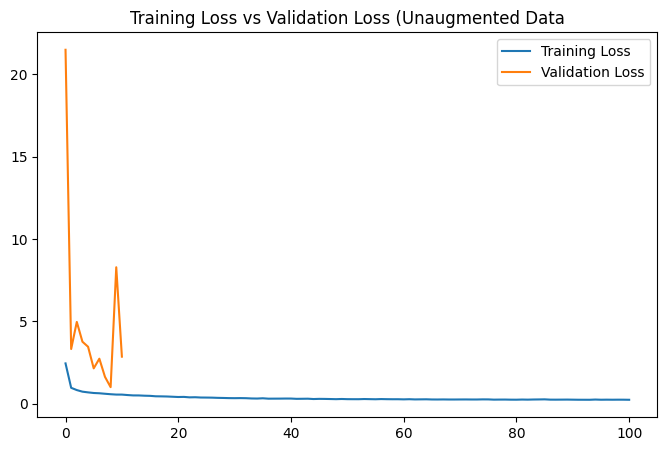

In [14]:

epoch_num = 100
def train(epoch,total_train_losses):
    model.train()
    model.to(device)
    loss_per_epoch = 0
    for i, (spec,supp,target) in enumerate(train_loader):
        spec,supp,target = spec.to(device,dtype=torch.float32), supp.to(device,dtype=torch.float32), target.to(device,dtype=torch.float32)
        optimiser.zero_grad()
        output = model(spec,supp)
        loss = weighted_mse_loss(output,target)
        loss_per_epoch += loss.item()
        loss.backward()
        optimiser.step()
    #scheduler.step()
    average_train_loss = loss_per_epoch / len(train_loader)
    total_train_losses.append(average_train_loss)
    print("Train Epoch: {} Loss: {}  ".format(epoch,average_train_loss))

def validation(epoch,total_val_losses):
    model.eval()
    model.to(device)
    with torch.no_grad():
        loss_per_epoch = 0
        for i, (spec,supp,target) in enumerate(val_loader):
            spec,supp,target = spec.to(device,dtype=torch.float32), supp.to(device,dtype=torch.float32), target.to(device,dtype=torch.float32)

            output = model(spec,supp)
            loss = weighted_mse_loss(output,target)
            loss_per_epoch += loss.item()
        average_val_loss = loss_per_epoch / len(val_loader)
        total_val_losses.append(average_val_loss)
        print("Validation Epoch: {} Loss: {}  ".format(epoch,average_val_loss))


total_train_losses = []
total_val_losses = []
validation_run = 10
for epoch in range(epoch_num+1):
    train(epoch,total_train_losses)
    if epoch % validation_run == 0:
        validation(epoch,total_val_losses)

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(range(len(total_train_losses)),total_train_losses,label = "Training Loss")
plt.plot(range(0,epoch_num+1,validation_run), total_val_losses,label = "Validation Loss")
plt.title("Training Loss vs Validation Loss (Unaugmented Data")
plt.legend()

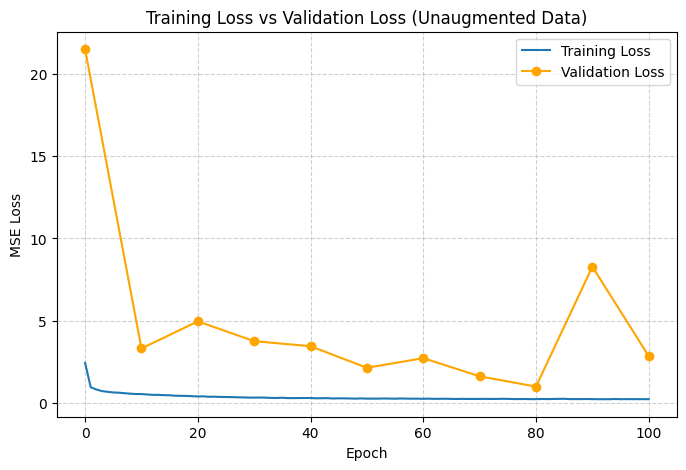

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Training gets plotted at every single epoch [0, 1, 2... 30]
train_x_axis = range(len(total_train_losses))
plt.plot(train_x_axis, total_train_losses, label="Training Loss")

# Validation gets plotted only at [0, 10, 20, 30]
val_x_axis = range(0, epoch_num + 1, validation_run)
# I added marker='o' so you can clearly see the specific validation points!
plt.plot(val_x_axis, total_val_losses, label="Validation Loss", marker='o', color='orange')

plt.title("Training Loss vs Validation Loss (Unaugmented Data)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6) # Adds a nice grid to read the values easier
plt.show()

In [33]:
spectrum_stack_testing, noise_stack_testing, wl_grid_testing, width_testing = load_spectral_data('./Hackathon_training/Test_SpectralData.hdf5')

In [34]:
test_supplementary = pd.read_csv('./Hackathon_training/Test_Supplementary_data.csv')
test_supplementary = test_supplementary.drop('Unnamed: 0', axis=1)
print(test_supplementary.head())

   planet_ID  star_distance  star_mass_kg  star_radius_m  star_temperature  \
0          0       100.0510  1.531871e+30    612216000.0            5053.0   
1          1        28.2938  1.536643e+30    542646000.0            5071.0   
2          2       258.8930  1.888989e+30    688743000.0            5416.0   
3          3      1010.2800  2.087830e+30    751356000.0            5900.0   
4          4      1070.1700  2.028178e+30    953109000.0            5866.0   

   planet_mass_kg  planet_orbital_period  planet_distance  planet_radius_m  \
0    4.994682e+25               3.646200         0.042501     1.751739e+07   
1    3.040857e+25              16.201656         0.114991     1.309706e+07   
2    9.850620e+25              88.406553         0.381830     2.628654e+07   
3    1.954940e+28               3.575320         0.046513     7.040038e+07   
4    5.997680e+25              31.588900         0.196877     1.964499e+07   

   planet_surface_gravity  
0               10.389141  
1     

In [35]:
x_test_supp = test_supplementary.iloc[:,1:].values
x_test_supp_scaled = supp_scaler.transform(x_test_supp)

In [36]:
x_combined_test = np.stack([spectrum_stack_testing, noise_stack_testing], axis=1)
x_test_supp_scaled = supp_scaler.transform(test_supplementary.iloc[:, 1:].values)

test_dataset = CombineDataset(x_combined_test, x_test_supp_scaled)  # no targets
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [37]:

test_dataset = CombineDataset(x_combined_test, x_test_supp_scaled)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


X_test_supp_scaled_internal = supp_scaler.transform(X_test_supp)


y_test_scaled = target_scaler.transform(y_test)

internal_test_dataset = CombineDataset(X_test_spec, X_test_supp_scaled_internal, y_test_scaled)
internal_test_loader = DataLoader(internal_test_dataset, batch_size=64, shuffle=False)

In [38]:
def testing(loader, target_scaler, model, has_targets=False):
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            spec = batch[0].to(device, dtype=torch.float32)
            supp = batch[1].to(device, dtype=torch.float32)
            prediction = model(spec, supp)
            all_predictions.append(prediction.cpu().numpy())
            if has_targets:
                all_targets.append(batch[2].cpu().numpy())

    all_predictions = np.vstack(all_predictions)
    predictions_rescaled = target_scaler.inverse_transform(all_predictions)

    if has_targets:
        all_targets = np.vstack(all_targets)
        ground_truth_rescaled = target_scaler.inverse_transform(all_targets)
        plot_predicted_vs_true(ground_truth_rescaled, predictions_rescaled)
        return predictions_rescaled, ground_truth_rescaled

    return predictions_rescaled

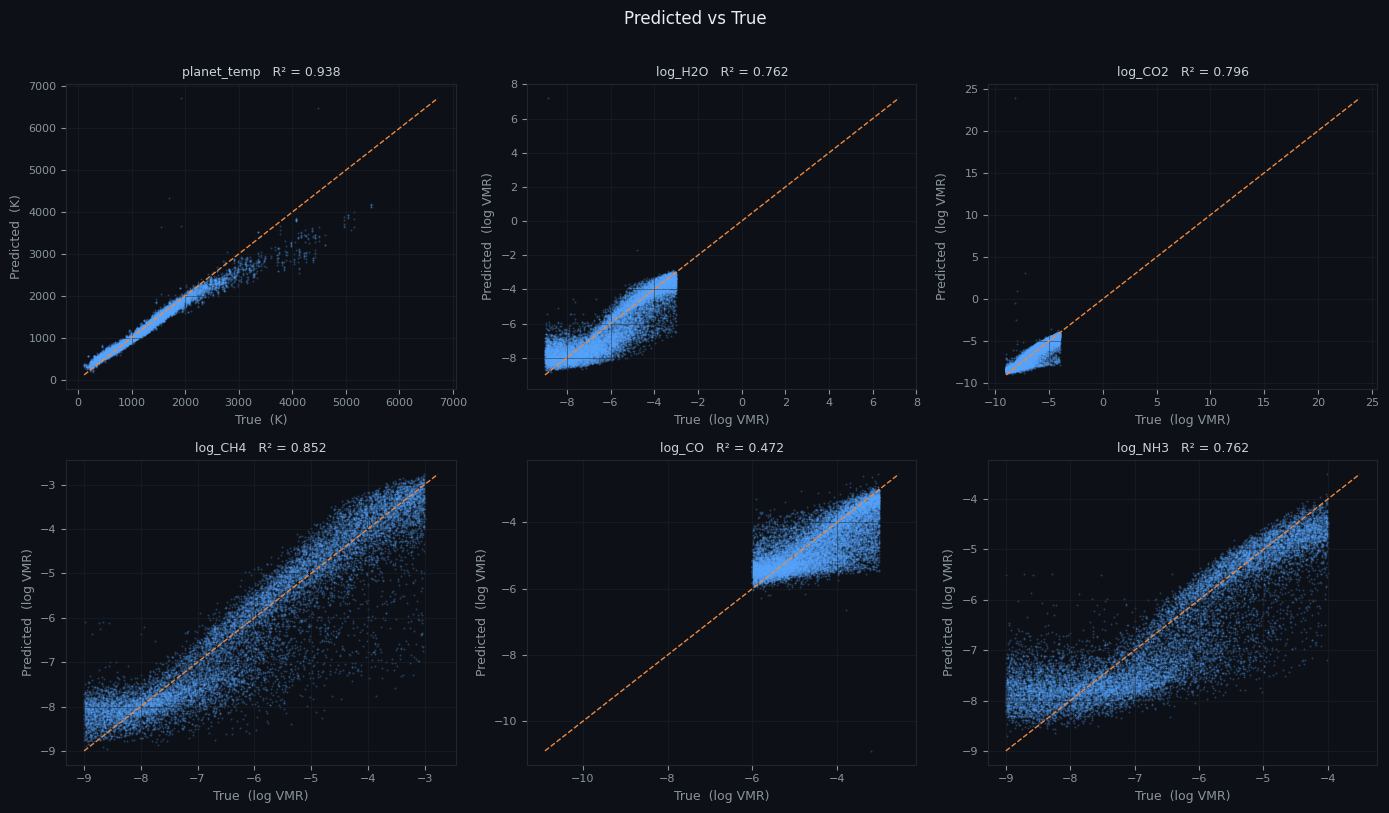

In [39]:
from utils import *
# Internal test set (has ground truth — plots automatically)
preds, gt = testing(internal_test_loader, target_scaler, model, has_targets=True)

# Leaderboard test set (no ground truth — no plot)
lb_preds = testing(internal_test_loader, target_scaler, model, has_targets=False)

In [ ]:
plot_residuals(y_test, y_pred_mean)

In [40]:
model.eval()
all_lb_predictions = []

with torch.no_grad():
    for batch in test_loader:
        spec = batch[0].to(device, dtype=torch.float32)
        supp = batch[1].to(device, dtype=torch.float32)
        prediction = model(spec, supp)
        all_lb_predictions.append(prediction.cpu().numpy())

all_lb_predictions = np.vstack(all_lb_predictions)
lb_y_pred_mean = target_scaler.inverse_transform(all_lb_predictions)

In [41]:
def mc_dropout_predictions(loader, model, n_samples=30):
    model.train()
    all_runs = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds = []
            for batch in loader:
                spec = batch[0].to(device, dtype=torch.float32)
                supp = batch[1].to(device, dtype=torch.float32)
                preds.append(model(spec, supp).cpu().numpy())
            all_runs.append(np.vstack(preds))
    all_runs = np.stack(all_runs)
    mean = target_scaler.inverse_transform(all_runs.mean(axis=0))
    std  = all_runs.std(axis=0) * target_scaler.scale_  # ← fixed
    std  = np.clip(std, 1e-6, None)
    return mean, std

In [42]:
from utils import array_to_submission

lb_y_pred_mean, lb_y_pred_std = mc_dropout_predictions(test_loader, model)

lb_y_pred_mean_sub = array_to_submission(lb_y_pred_mean, planet_ids=np.arange(0, len(lb_y_pred_mean)))
lb_y_pred_std_sub  = array_to_submission(lb_y_pred_std,  planet_ids=np.arange(0, len(lb_y_pred_mean)))

In [26]:
import requests

submission_url = "https://www.ariel-datachallenge.space/api/score/calculate/"
data = {
    "secret_key": "Scorch-9b",
    "team_name":  "KELT-9-b",
    "team_no":    "20",
}
submission_files = {
    "mu_file":  ("mu_predictions.csv",  lb_y_pred_mean_sub.to_csv(index=True), "text/csv"),
    "std_file": ("std_predictions.csv", lb_y_pred_std_sub.to_csv(index=True),  "text/csv"),
}

response = requests.post(submission_url, data=data, files=submission_files, timeout=60)

if response.status_code == 200:
    print("Submission successful! Score:", response.json()["score"])
else:
    print("Failed:", response.status_code, response.json()["error"])

Failed: 400 The deadline has passed


In [44]:
from utils import array_to_submission, compute_participant_score

# 1. Run MC Dropout on your INTERNAL test loader
internal_mu, internal_std = mc_dropout_predictions(internal_test_loader, model)

# 'gt' is the unscaled ground truth array you generated earlier in the testing() cell
# We need an array of IDs just to satisfy the submission format
test_ids = np.arange(len(gt))

# 2. Convert all three arrays into the official Submission DataFrame format
y_test_sub = array_to_submission(gt, planet_ids=test_ids)
y_pred_mean_sub = array_to_submission(internal_mu, planet_ids=test_ids)
y_pred_std_sub = array_to_submission(internal_std, planet_ids=test_ids)

# 3. Calculate your official score!
final_score = compute_participant_score(y_test_sub, y_pred_mean_sub, y_pred_std_sub)

print(f"My Final Local GLL Score: {final_score}")

My Final Local GLL Score: {'score': 0.8336127854384491, 'mean_crps': 0.09593709781015786, 'crps_per_param': array([0.06825236, 0.09780203, 0.06643875, 0.06660752, 0.12009977,
       0.15642216]), 'score_per_param': array([0.87381521, 0.83220514, 0.88499673, 0.88543395, 0.79518728,
       0.7300384 ])}


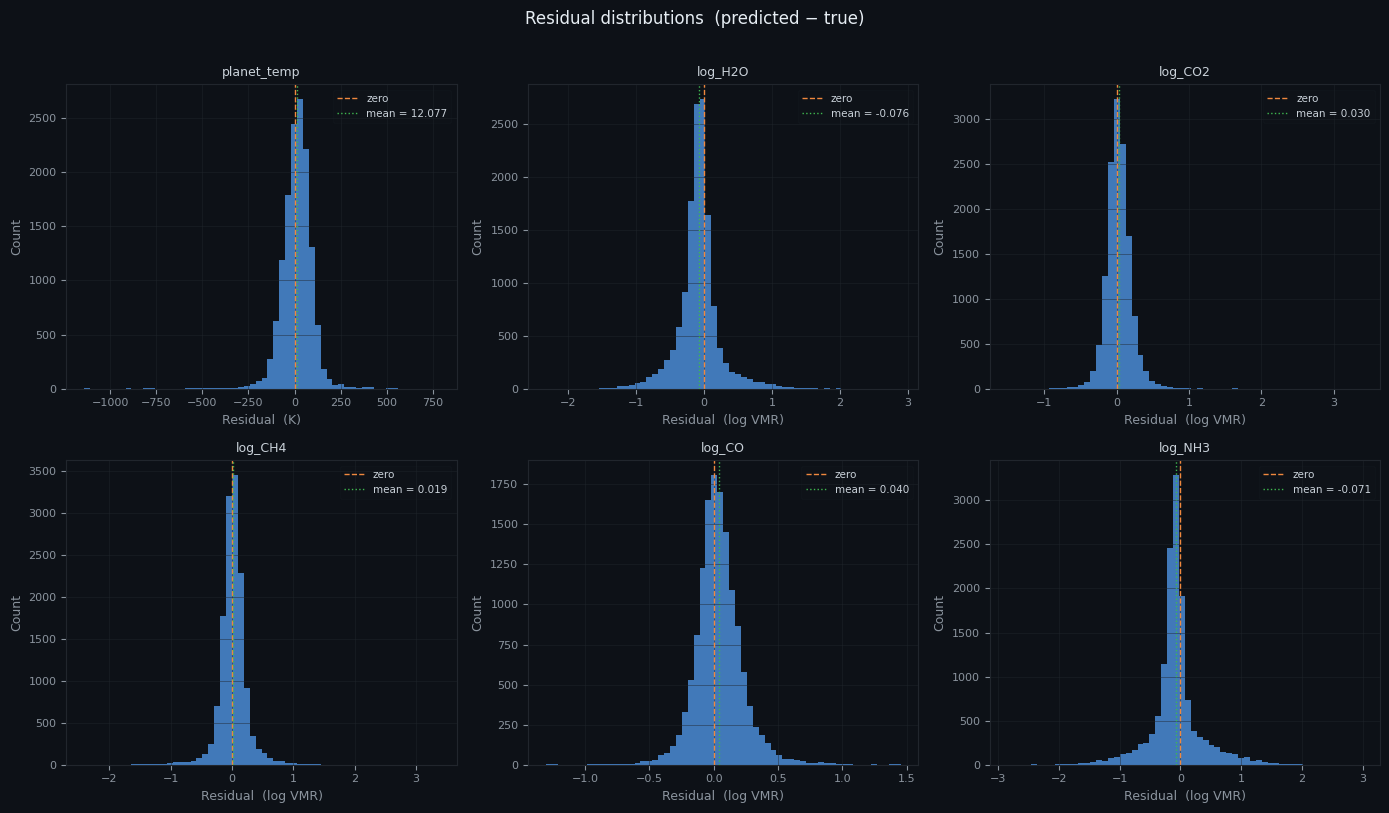

In [45]:
plot_residuals(gt, internal_mu)

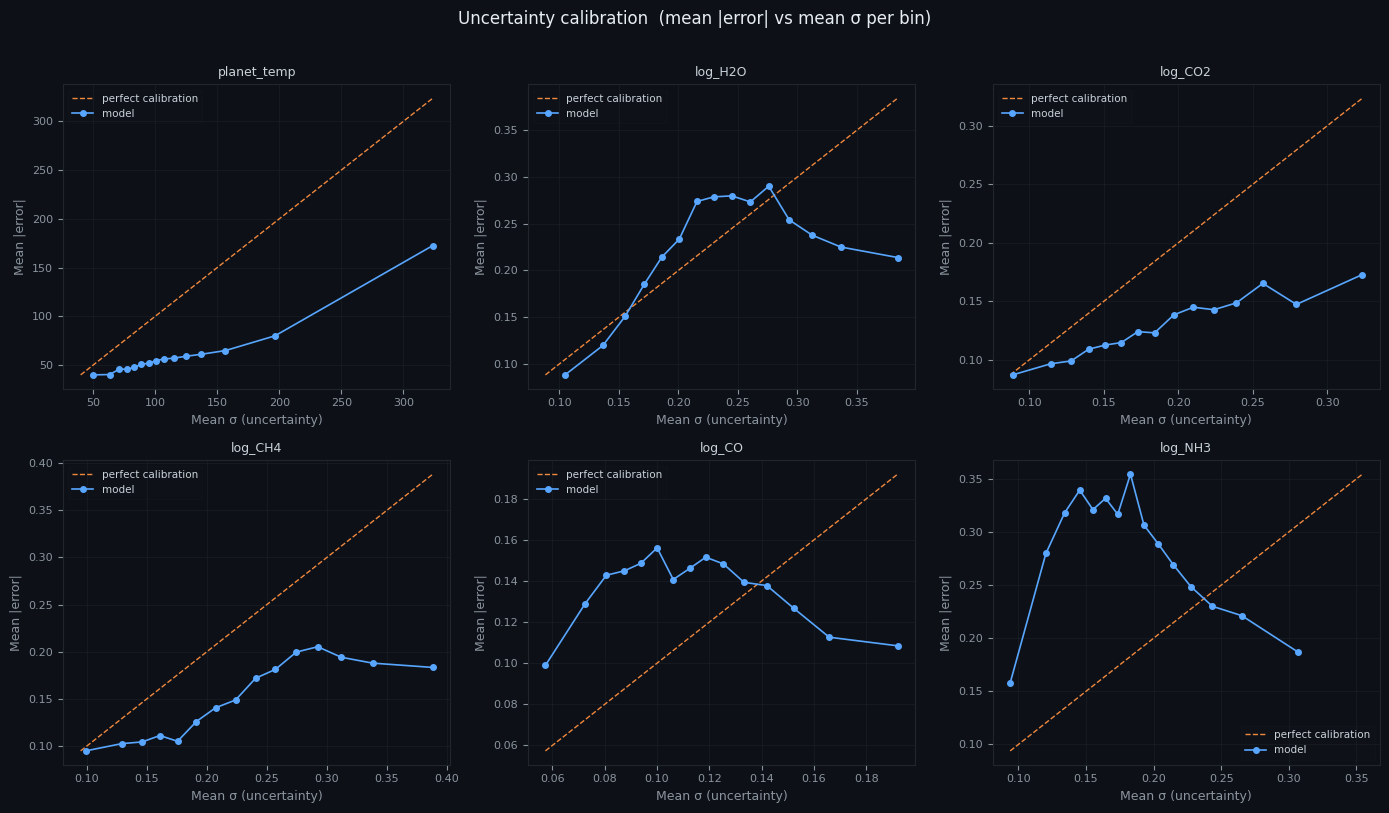

In [46]:
plot_calibration(gt, internal_mu, internal_std)

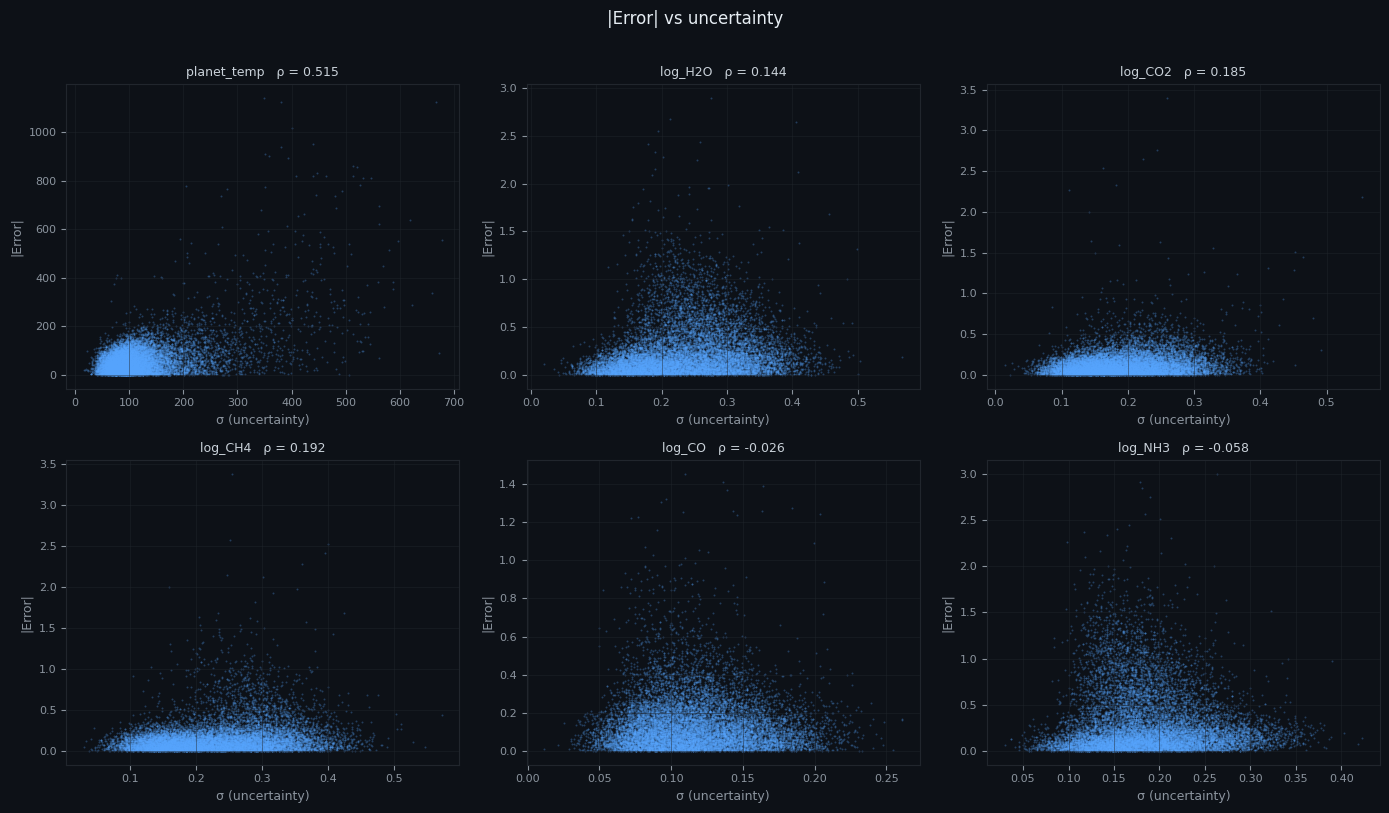

In [47]:
plot_error_vs_uncertainty(gt, internal_mu, internal_std)

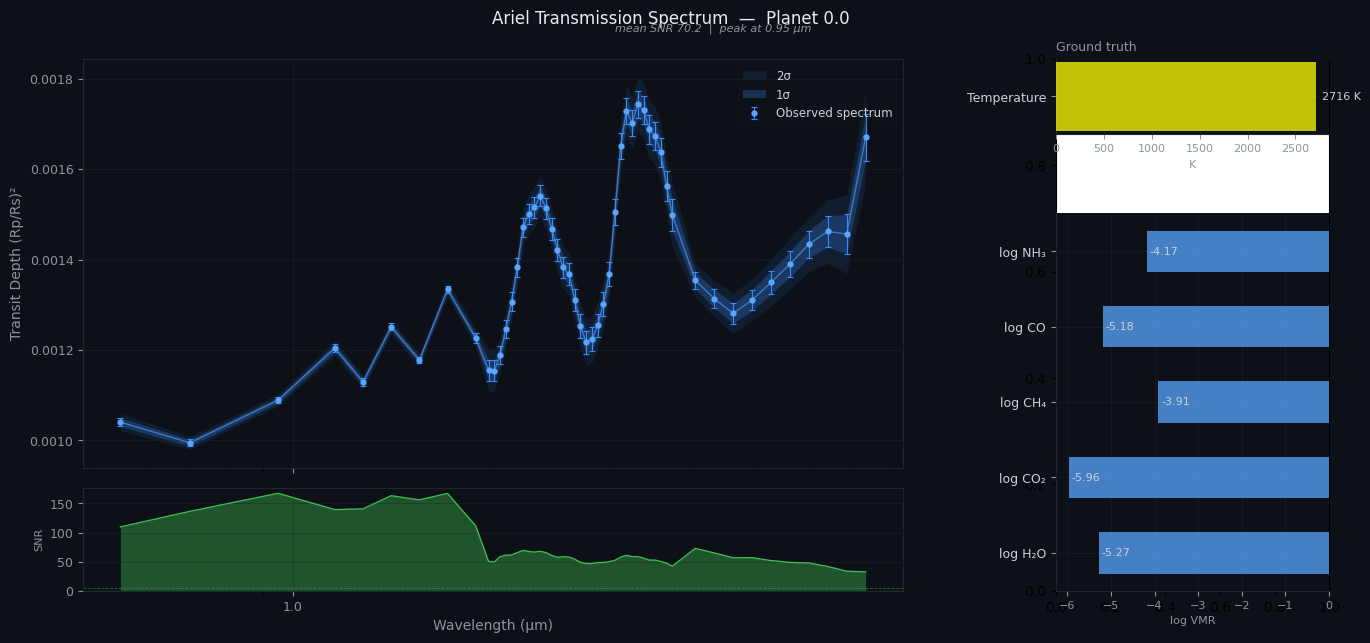

In [48]:
plot_spectrum(
    planet_id=0,
    spectrum_stack=spectrum_stack_testing, # Your raw spectrum array
    noise_stack=noise_stack_testing,       # Your raw noise array
    wl_grid=wl_grid_testing,               # Your wavelength grid
    y_true=y_test_sub                      # The formatted DataFrame
)